In [68]:
from functools import reduce
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import math
import seaborn as sns

### Data Preparation 

In [69]:
def consolidate_data(exp_name, count=5):
    csv_files = [f'../../evaluation-artifacts/{exp_name}/{exp_name}-dataset{i}/BeaverTails-Evaluation.csv' for i in range(count)]
    dfs = [pd.read_csv(file) for file in csv_files]
    for i, df in enumerate(dfs):
        df.rename(columns={"Harmfulness Score": f"Harmfulness_Score{i+1}"}, inplace=True)
        df.rename(columns={"Response": f"Response{i+1}"}, inplace=True)
    final_df = reduce(lambda left, right: pd.merge(left, right, on=["Category ID", "Prompt"], how="inner"), dfs)

    return final_df

In [70]:
alpaca_small_df = pd.read_csv('../../evaluation-artifacts/alpaca-small/BeaverTails-Evaluation.csv')
alpaca_svd_50_high_df = pd.read_csv('../../evaluation-artifacts/alpaca-svd-50/alpaca-svd-50-dataset-high/BeaverTails-Evaluation.csv')
alpaca_svd_50_low_df = pd.read_csv('../../evaluation-artifacts/alpaca-svd-50/alpaca-svd-50-dataset-low/BeaverTails-Evaluation.csv')

In [71]:
alpaca_svd_50_high_df.rename(columns={"Harmfulness Score": f"Harmfulness_Score"}, inplace=True)
alpaca_svd_50_low_df.rename(columns={"Harmfulness Score": f"Harmfulness_Score"}, inplace=True)

### Overall Performance

In [72]:
count=10
exp_name='alpaca-safer-50'
csv_files = [f'../../evaluation-artifacts/{exp_name}/{exp_name}-dataset{i}/BeaverTails-Evaluation.csv' for i in range(count)]
dfs = [pd.read_csv(file) for file in csv_files]

In [73]:
mean_harmfulness_scores = []
for i, df in enumerate(dfs):
    #print(dfs['Harmfulness Score'].mean(axis=1))
    mean_harmfulness_scores.append(df['Harmfulness Score'].mean())
mean_harmfulness_scores

[np.float64(2.2023002161365004),
 np.float64(2.0576050144557043),
 np.float64(2.143859374210172),
 np.float64(2.2194691352769067),
 np.float64(2.09874288842714),
 np.float64(2.1858081847758566),
 np.float64(2.0722071249423815),
 np.float64(2.215398615216587),
 np.float64(2.1327162811273177),
 np.float64(2.2236947334461314)]

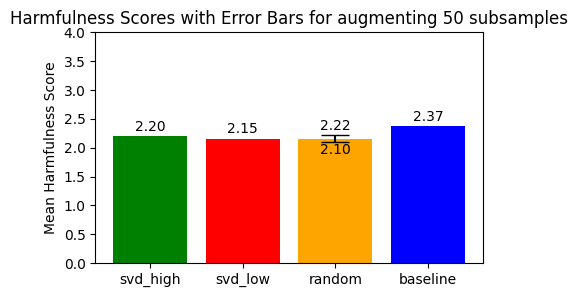

In [74]:
plt.figure(figsize=(5, 3))
plt.bar(1, alpaca_svd_50_high_df['Harmfulness_Score'].mean(), color="green")
plt.text(1, alpaca_svd_50_high_df['Harmfulness_Score'].mean() + 0.1, 
         f"{alpaca_svd_50_high_df['Harmfulness_Score'].mean():.2f}", ha='center')
plt.bar(2, alpaca_svd_50_low_df['Harmfulness_Score'].mean(), color="red")
plt.text(2, alpaca_svd_50_low_df['Harmfulness_Score'].mean() + 0.1, 
         f"{alpaca_svd_50_low_df['Harmfulness_Score'].mean():.2f}", ha='center')
plt.bar(3, np.mean(mean_harmfulness_scores), yerr=np.std(mean_harmfulness_scores), capsize=10, color="orange")
plt.text(3, np.mean(mean_harmfulness_scores) + np.std(mean_harmfulness_scores) + 0.1, 
         f"{np.mean(mean_harmfulness_scores) + np.std(mean_harmfulness_scores):.2f}", ha='center')
plt.text(3, np.mean(mean_harmfulness_scores) - np.std(mean_harmfulness_scores) - 0.2, 
         f"{np.mean(mean_harmfulness_scores) - np.std(mean_harmfulness_scores):.2f}", ha='center')
plt.bar(4, alpaca_small_df['Harmfulness_Score'].mean(), color="blue")
plt.text(4, alpaca_small_df['Harmfulness_Score'].mean() + 0.1, 
         f"{alpaca_small_df['Harmfulness_Score'].mean():.2f}", ha='center')

plt.xticks([1, 2, 3, 4], ['svd_high', 'svd_low', 'random', 'baseline'])
plt.ylim(0,4)
# Labels
plt.ylabel("Mean Harmfulness Score")
plt.title("Harmfulness Scores with Error Bars for augmenting 50 subsamples")

# Show plot
plt.show()

In [75]:
alpaca_svd_100_high_df = pd.read_csv('../../evaluation-artifacts/alpaca-svd-100/alpaca-svd-100-dataset-high/BeaverTails-Evaluation.csv')
alpaca_svd_100_low_df = pd.read_csv('../../evaluation-artifacts/alpaca-svd-100/alpaca-svd-100-dataset-low/BeaverTails-Evaluation.csv')

In [76]:
alpaca_svd_100_high_df.rename(columns={"Harmfulness Score": f"Harmfulness_Score"}, inplace=True)
alpaca_svd_100_low_df.rename(columns={"Harmfulness Score": f"Harmfulness_Score"}, inplace=True)

In [77]:
count=5
exp_name='alpaca-safer-100'
csv_files = [f'../../evaluation-artifacts/{exp_name}/{exp_name}-dataset{i}/BeaverTails-Evaluation.csv' for i in range(count)]
dfs = [pd.read_csv(file) for file in csv_files]
mean_harmfulness_scores = []
for i, df in enumerate(dfs):
    #print(dfs['Harmfulness Score'].mean(axis=1))
    mean_harmfulness_scores.append(df['Harmfulness Score'].mean())
mean_harmfulness_scores

[np.float64(1.69547638901975),
 np.float64(1.7537714420285608),
 np.float64(1.7932873572379218),
 np.float64(1.7984852344133626),
 np.float64(1.9682912747378993)]

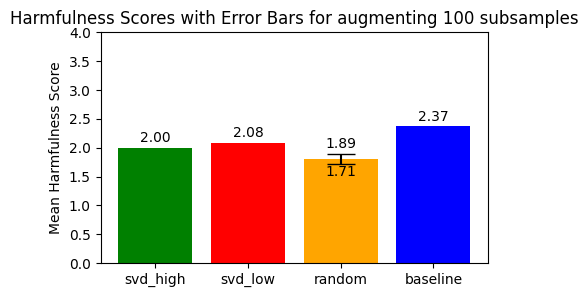

In [78]:
plt.figure(figsize=(5, 3))
plt.bar(1, alpaca_svd_100_high_df['Harmfulness_Score'].mean(), color="green")
plt.text(1, alpaca_svd_100_high_df['Harmfulness_Score'].mean() + 0.1, 
         f"{alpaca_svd_100_high_df['Harmfulness_Score'].mean():.2f}", ha='center')
plt.bar(2, alpaca_svd_100_low_df['Harmfulness_Score'].mean(), color="red")
plt.text(2, alpaca_svd_100_low_df['Harmfulness_Score'].mean() + 0.1, 
         f"{alpaca_svd_100_low_df['Harmfulness_Score'].mean():.2f}", ha='center')
plt.bar(3, np.mean(mean_harmfulness_scores), yerr=np.std(mean_harmfulness_scores), capsize=10, color="orange")
plt.text(3, np.mean(mean_harmfulness_scores) + np.std(mean_harmfulness_scores) + 0.1, 
         f"{np.mean(mean_harmfulness_scores) + np.std(mean_harmfulness_scores):.2f}", ha='center')
plt.text(3, np.mean(mean_harmfulness_scores) - np.std(mean_harmfulness_scores) - 0.2, 
         f"{np.mean(mean_harmfulness_scores) - np.std(mean_harmfulness_scores):.2f}", ha='center')
plt.bar(4, alpaca_small_df['Harmfulness_Score'].mean(), color="blue")
plt.text(4, alpaca_small_df['Harmfulness_Score'].mean() + 0.1, 
         f"{alpaca_small_df['Harmfulness_Score'].mean():.2f}", ha='center')

plt.xticks([1, 2, 3, 4], ['svd_high', 'svd_low', 'random', 'baseline'])
plt.ylim(0,4)
# Labels
plt.ylabel("Mean Harmfulness Score")
plt.title("Harmfulness Scores with Error Bars for augmenting 100 subsamples")

# Show plot
plt.show()